In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
data_path = '../data/NonLinear_data.npy'
data = np.load(data_path, allow_pickle=True).item()  # load dữ liệu
data
X,y=data['X'],data['labels']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Số lượng classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

X shape: (300, 2)
y shape: (300,)
Số lượng classes: 3
Classes: [0 1 2]


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Split temp thành val và test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (210, 2)
X_val shape: (45, 2)
X_test shape: (45, 2)
y_train shape: (210,)
y_val shape: (45,)
y_test shape: (45,)


In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)
X_val = scaler.transform(X_val)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Val set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Train set: 210 samples
Val set: 45 samples
Test set: 45 samples


In [22]:
def one_hot_encode(labels, num_classes):
    """
    Chuyển labels từ integer sang one-hot encoding
    Input: labels shape (n,)
    Output: one-hot shape (n, num_classes)
    """
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot
num_classes = len(np.unique(y))
y_train_onehot = one_hot_encode(y_train, num_classes)
y_test_onehot = one_hot_encode(y_test, num_classes)
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"\nVí dụ label gốc: {y_train[:5]}")
print(f"One-hot encoding:\n{y_train_onehot[:5]}")

y_train_onehot shape: (210, 3)

Ví dụ label gốc: [2 1 0 1 1]
One-hot encoding:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [12]:
class Linear:
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.uniform(-1, 1, (output_dim, input_dim))
        self.biases = np.zeros((output_dim,))
        self.input = None
        self.num_params = output_dim * input_dim + output_dim

    def forward(self, X):
        self.input = X
        return X @ self.weights.T + self.biases
        
    def backward(self, grad_output, lr):
        m = self.input.shape[0]
        d_weights = grad_output.T @ self.input / m
        d_biases = np.mean(grad_output, axis=0)
        self.weights -= lr * d_weights
        self.biases -= lr * d_biases
        grad_input = grad_output @ self.weights
        return grad_input

In [13]:
class ReLU:
    def __init__(self):
        self.input = None
    
    def forward(self, X):
        self.input = X
        return np.maximum(0, X)
    
    def backward(self, grad_output):
        grad_input = grad_output * (self.input > 0).astype(float)
        return grad_input

class Softmax:
    def forward(self, X):
        exp_scores = np.exp(X - np.max(X, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

In [14]:
class NeuralNetwork:
    def __init__(self, input_dim, output_dim):
        # Kiến trúc: Input -> 100 -> 200 -> 100 -> Output
        self.linear1 = Linear(input_dim, 100)
        self.relu1 = ReLU()
        self.linear2 = Linear(100, 200)
        self.relu2 = ReLU()
        self.linear3 = Linear(200, 100)
        self.relu3 = ReLU()
        self.linear4 = Linear(100, output_dim)
        self.softmax = Softmax()
        
        total_params = (self.linear1.num_params + self.linear2.num_params + 
                       self.linear3.num_params + self.linear4.num_params)
        print(f"Total parameters: {total_params}")
    
    def forward(self, X):
        out = self.linear1.forward(X)
        out = self.relu1.forward(out)
        out = self.linear2.forward(out)
        out = self.relu2.forward(out)
        out = self.linear3.forward(out)
        out = self.relu3.forward(out)
        out = self.linear4.forward(out)
        out = self.softmax.forward(out)
        return out
    
    def backward(self, y_true, y_pred, lr):
        m = y_true.shape[0]
        num_classes = y_pred.shape[1]
        y_onehot = np.zeros((m, num_classes))
        y_onehot[np.arange(m), y_true] = 1
        grad_softmax = (y_pred - y_onehot) / m
        
        grad = self.linear4.backward(grad_softmax, lr)
        grad = self.relu3.backward(grad)
        grad = self.linear3.backward(grad, lr)
        grad = self.relu2.backward(grad)
        grad = self.linear2.backward(grad, lr)
        grad = self.relu1.backward(grad)
        grad = self.linear1.backward(grad, lr)
        return grad

In [15]:
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]
    num_classes = y_pred.shape[1]
    y_onehot = np.zeros((m, num_classes))
    y_onehot[np.arange(m), y_true] = 1
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y_onehot * np.log(y_pred), axis=1))
    return loss
def train_model(model, epochs, lr=0.01):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = model.forward(X_train)
        
        # Backward pass
        model.backward(y_train, y_pred, lr=lr)
        
        # Compute metrics
        train_loss = cross_entropy_loss(y_train, y_pred)
        train_losses.append(train_loss)
        train_acc = np.mean(np.argmax(y_pred, axis=1) == y_train)
        
        # Validation
        y_pred_val = model.forward(X_val)
        val_loss = cross_entropy_loss(y_val, y_pred_val)
        val_losses.append(val_loss)
        val_acc = np.mean(np.argmax(y_pred_val, axis=1) == y_val)
        
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return train_losses, val_losses

In [23]:
model = NeuralNetwork(input_dim=2, output_dim=3)  # 2 features, 3 classes
train_losses, val_losses = train_model(model, epochs=1000, lr=0.01)

Total parameters: 40903
Epoch 1/1000, Train Loss: 18.0911, Train Acc: 0.3333, Val Loss: 17.3349, Val Acc: 0.3333
Epoch 100/1000, Train Loss: 6.7807, Train Acc: 0.5476, Val Loss: 4.3147, Val Acc: 0.5556
Epoch 200/1000, Train Loss: 4.7719, Train Acc: 0.6429, Val Loss: 5.1370, Val Acc: 0.6444
Epoch 300/1000, Train Loss: 3.9139, Train Acc: 0.7095, Val Loss: 4.0673, Val Acc: 0.6889
Epoch 400/1000, Train Loss: 3.0836, Train Acc: 0.7286, Val Loss: 4.0837, Val Acc: 0.6667
Epoch 500/1000, Train Loss: 2.3279, Train Acc: 0.7667, Val Loss: 3.3065, Val Acc: 0.6667
Epoch 600/1000, Train Loss: 1.8705, Train Acc: 0.7905, Val Loss: 2.7264, Val Acc: 0.6667
Epoch 700/1000, Train Loss: 1.4856, Train Acc: 0.8095, Val Loss: 2.1400, Val Acc: 0.6889
Epoch 800/1000, Train Loss: 1.0961, Train Acc: 0.8095, Val Loss: 1.5568, Val Acc: 0.6889
Epoch 900/1000, Train Loss: 0.7962, Train Acc: 0.8190, Val Loss: 1.0942, Val Acc: 0.7111
Epoch 1000/1000, Train Loss: 0.6243, Train Acc: 0.8667, Val Loss: 0.8113, Val Acc: 0.7

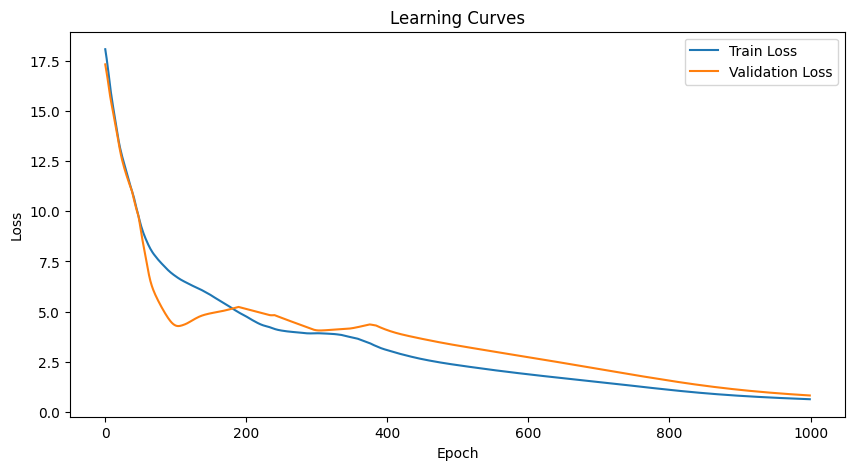

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves')
plt.show()